In [1]:
# import sys
# import operator
# import scipy as sp
# import statsmodels.api as sm
# from statsmodels.tools import add_constant
# from statsmodels.regression.linear_model import RegressionResults
# import seaborn as sns
# import sklearn as sk
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.model_selection import KFold
# from sklearn.linear_model import LinearRegression
# from sklearn.linear_model import Ridge
# from sklearn.linear_model import Lasso
# from sklearn.preprocessing import PolynomialFeatures
# from sklearn.decomposition import PCA



%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn import metrics
import scipy.optimize as opt
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("land_type.csv")
x = df.drop("land_type", axis=1).values
y = df['land_type']


### Plotting data

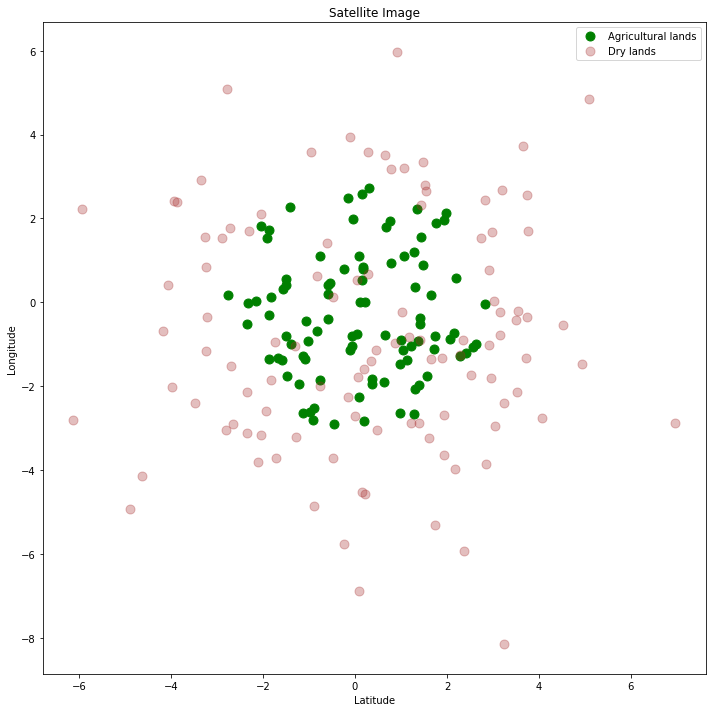

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    
ax.plot(x[y == 1, 0], x[y == 1, 1], 'o',c='green', markersize=9,label='Agricultural lands')
ax.plot(x[y == 0, 0], x[y == 0, 1], 'o',c='brown', markersize=9,label='Dry lands', alpha=0.3)
ax.set_xlabel('Latitude')
ax.set_ylabel('Longitude')
ax.set_title('Satellite Image')

ax.legend()
plt.tight_layout()
plt.show() 

Accuracy= 0.88


/usr/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:938: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


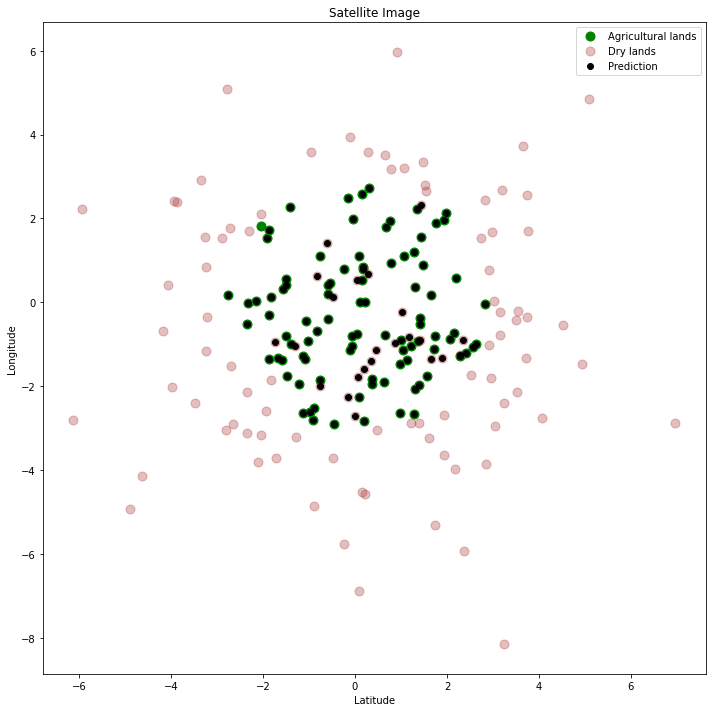

/usr/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:938: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy= 0.875


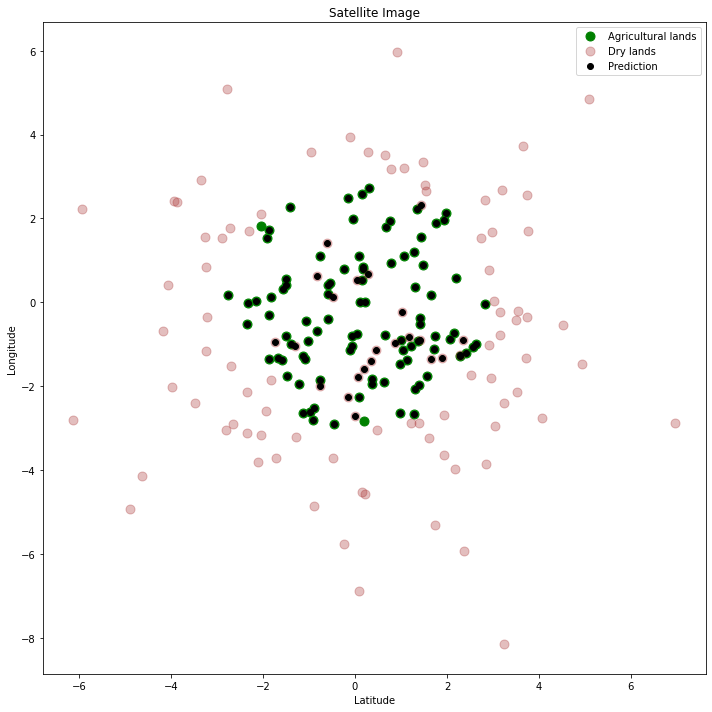

/usr/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:938: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy= 0.875


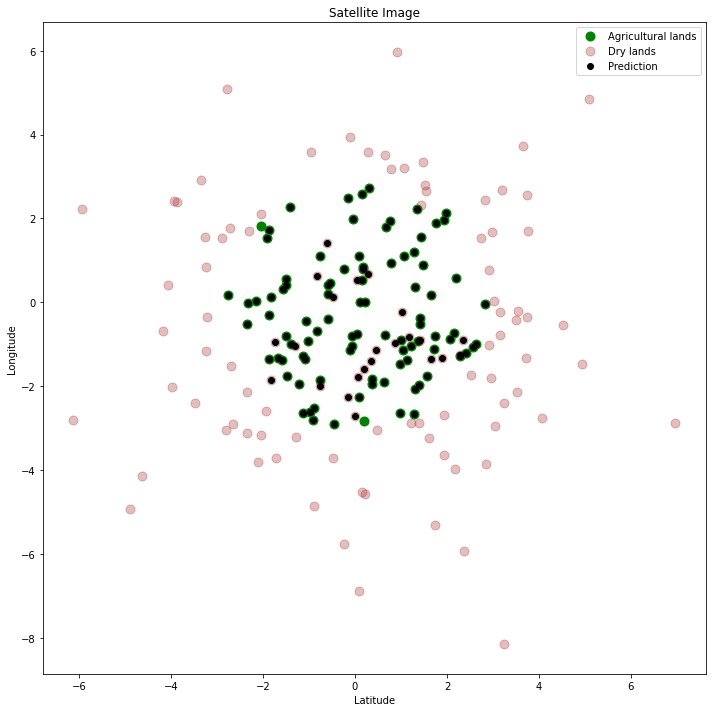

/usr/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:938: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy= 0.885


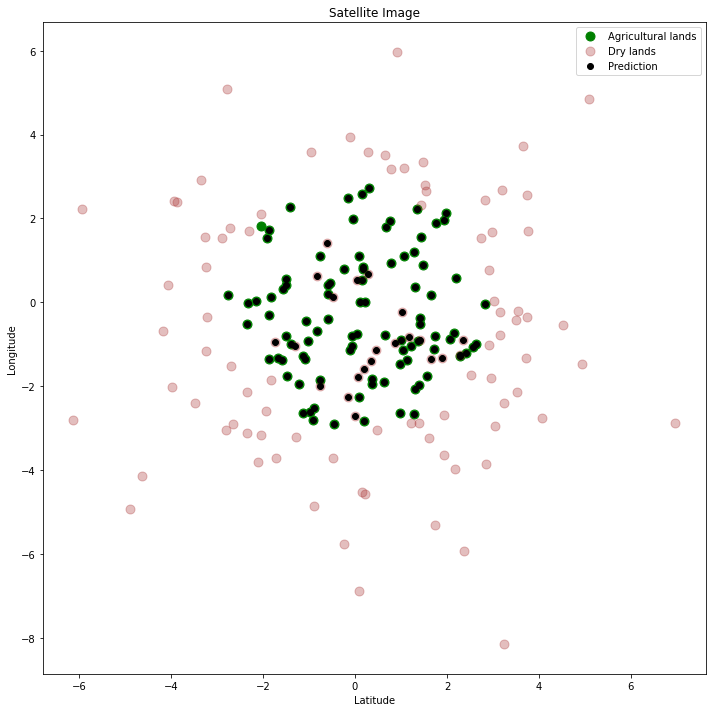

In [4]:
#clist = [0.00000000001,0.00001,0.1,1,100000,100000000000]
clist = [0.00001,1,100000,100000000]
for c in clist:
    #Select degree of the curve
    degree = 10

    #Compute the polynomial features
    x1 = PolynomialFeatures(degree).fit_transform(x)
    lr = LogisticRegression(C=c)
    lr.fit(x1, y)
    yp = lr.predict(x1)

    validation_accuracy = accuracy_score(y, yp)

    print("Accuracy=",validation_accuracy)
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    ax.plot(x[y == 1, 0], x[y == 1, 1], 'o',c='green', markersize=9,label='Agricultural lands')
    ax.plot(x[y == 0, 0], x[y == 0, 1], 'o',c='brown', markersize=9,label='Dry lands', alpha=0.3)
    ax.plot(x[yp == 1, 0], x[yp == 1, 1], 'o',c='black', markersize=6,label='Prediction')

    ax.set_xlabel('Latitude')
    ax.set_ylabel('Longitude')
    ax.set_title('Satellite Image')

    ax.legend()
    plt.tight_layout()
    plt.show() 

In [ ]:
#--------  plot_tree_boundary
# A function that visualizes the data and the decision boundaries
# Input: 
#      x (predictors)
#      y (labels)
#      model (the classifier you want to visualize)
#      title (title for plot)
#      ax (a set of axes to plot on)
# Returns: 
#      ax (axes with data and decision boundaries)

def plot_boundary(x, y, model, title, ax, plot_data=True, fill=True, color='Greens'):
    

    if plot_data:
        # PLOT DATA
        ax.scatter(x[y==1,0], x[y==1,1], c='green')
        ax.scatter(x[y==0,0], x[y==0,1], c='grey')
    
    # CREATE MESH
    interval = np.arange(min(x.min(), y.min()),max(x.max(), y.max()),0.01)
    n = np.size(interval)
    x1, x2 = np.meshgrid(interval, interval)
    x1 = x1.reshape(-1,1)
    x2 = x2.reshape(-1,1)
    xx = np.concatenate((x1, x2), axis=1)

    # PREDICT ON MESH POINTS
    yy = model.predict(xx)    
    yy = yy.reshape((n, n))

    # PLOT DECISION SURFACE
    x1 = x1.reshape(n, n)
    x2 = x2.reshape(n, n)
    if fill:
        ax.contourf(x1, x2, yy, alpha=0.1, cmap=color)
    else:
        ax.contour(x1, x2, yy, alpha=0.1, cmap=color)
    
    # LABEL AXIS, TITLE
    ax.set_title(title)
    ax.set_xlabel('Latitude')
    ax.set_ylabel('Longitude')
    
    return ax

In [6]:
#--------  fit_and_plot_dt
# Fit decision tree with on given data set with given depth, and plot the data/model
# Input: 
#      fname (string containing file name)
#      depth (depth of tree)

def fit_and_plot_dt(x, y, c, title, ax, plot_data=True, fill=True, color='Blues'):

    lreg = LogisticRegression(C=c)

    lreg.fit(x, y)

    # PLOT DECISION TREE BOUNDARY
    ax = plot_boundary(x, y, lreg, title, ax, plot_data, fill, color)
    
    return ax

In [7]:
npoints = 200 
data = np.random.multivariate_normal([0, 0], np.eye(2) * 5, size=npoints)
data = np.hstack((data, np.zeros((npoints, 1))))

data[data[:, 0]**2 + data[:, 1]**2 < 3**2, 2] = np.random.choice([0, 1], len(data[data[:, 0]**2 + data[:, 1]**2 < 3**2]), p=[0.2, 0.8])

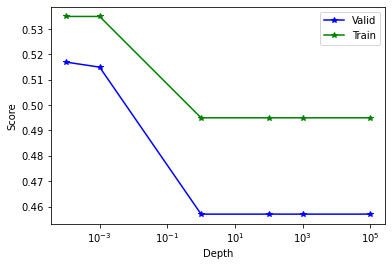

In [8]:
#Overfitting

depths = [0.0001,0.001,1,100, 1000, 100000]

test_data = np.random.multivariate_normal([0, 0], np.eye(2) * 5, size=1000)
test_data = np.hstack((test_data, np.zeros((1000, 1))))
test_data[test_data[:, 0]**2 + test_data[:, 1]**2 < 3**2, 2] = np.random.choice([0, 1], len(test_data[test_data[:, 0]**2 + test_data[:, 1]**2 < 3**2]), p=[0.2, 0.8])
x_test = test_data[:, :-1]
y_test = test_data[:, -1]

scores = []
scores_train = []
for c in depths:
    lreg = LogisticRegression(C=c)
    lreg.fit(x, y)
    scores.append(lreg.score(x_test, y_test))
    scores_train.append(lreg.score(x, y))
    
plt.plot(depths, scores, 'b*-', label = 'Valid')
plt.plot(depths, scores_train, 'g*-', label = 'Train')
plt.xlabel('Depth')
plt.ylabel('Score')
plt.xscale('log')
plt.legend()

In [ ]:
#Variance comparison between simple and complex models
depths = [0.0000001, 1, 100000000]

fig, ax = plt.subplots(1, len(depths), figsize=(10, 10))

for d in range(len(depths)):
    for i in range(10):
        new_data = np.random.multivariate_normal([0, 0], np.eye(2) * 5, size=200)
        new_data = np.hstack((new_data, np.zeros((200, 1))))
        new_data[new_data[:, 0]**2 + new_data[:, 1]**2 < 3**2, 2] = np.random.choice([0, 1], len(new_data[new_data[:, 0]**2 + new_data[:, 1]**2 < 3**2]), p=[0.2, 0.8])
        x = new_data[:, :-1]
        y = new_data[:, -1]
        ax[d] = fit_and_plot_dt(x, y, depths[d], 'Depth {}'.format(depths[d]), ax[d], plot_data=False, fill=False) 
        ax[d].set_xlim(-6, 6)
        ax[d].set_ylim(-6, 6)
        
plt.tight_layout()
plt.show() 

## ALT

### Splitting the dataset

In [5]:
X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.25, random_state=0)

In [8]:
def mapFeature(X1, X2):
    degree = 6
    out = np.ones(x.shape[0])[:,np.newaxis]
    for i in range(1, degree+1):
        for j in range(i+1):
            out = np.hstack((out, np.multiply(np.power(X1, i-j),                                     np.power(X2, j))[:,np.newaxis]))
    return out

X = mapFeature(x[:,0], x[:,1])

In [9]:
def sigmoid(x):
  return 1/(1+np.exp(-x))

In [10]:
def lrCostFunction(theta_t, X_t, y_t, lambda_t):
    m = len(y_t)
    J = (-1/m) * (y_t.T @ np.log(sigmoid(X_t @ theta_t)) + (1 - y_t.T) @ np.log(1 - sigmoid(X_t @ theta_t)))
    reg = (lambda_t/(2*m)) * (theta_t[1:].T @ theta_t[1:])
    J = J + reg
    return J

In [11]:
def lrGradientDescent(theta, X, y, lambda_t):
    m = len(y)
    grad = np.zeros([m,1])
    grad = (1/m) * X.T @ (sigmoid(X @ theta) - y)
    grad[1:] = grad[1:] + (lambda_t / m) * theta[1:]
    return grad

In [12]:
(m, n) = X.shape
y = y[:, np.newaxis]
theta = np.zeros((n,1))
lmbda = 1
J = lrCostFunction(theta, X, y, lmbda)
print(J)

[[0.69314718]]


In [14]:
output = opt.fmin_tnc(func = lrCostFunction, x0 = theta.flatten(), fprime = lrGradientDescent, \
                         args = (X, y.flatten(), lmbda))
theta = output[0]


<ipython-input-9-bb43d9876711>:2: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-x))
<ipython-input-10-7e13fb3e922e>:3: RuntimeWarning: divide by zero encountered in log
  J = (-1/m) * (y_t.T @ np.log(sigmoid(X_t @ theta_t)) + (1 - y_t.T) @ np.log(1 - sigmoid(X_t @ theta_t)))
<ipython-input-10-7e13fb3e922e>:3: RuntimeWarning: invalid value encountered in matmul
  J = (-1/m) * (y_t.T @ np.log(sigmoid(X_t @ theta_t)) + (1 - y_t.T) @ np.log(1 - sigmoid(X_t @ theta_t)))


In [15]:
pred = [sigmoid(np.dot(X, theta)) >= 0.5]
np.mean(pred == y.flatten()) * 100

83.5

In [ ]:
u = np.linspace(-6, 6, 200)
v = np.linspace(-6, 6, 200)
z = np.zeros((len(u), len(v)))

def mapFeatureForPlotting(X1, X2):
    degree = 6
    out = np.ones(1)
    for i in range(1, degree+1):
        for j in range(i+1):
            out = np.hstack((out, np.multiply(np.power(X1, i-j), np.power(X2, j))))
    return out

for i in range(len(u)):
    for j in range(len(v)):
        z[i,j] = np.dot(mapFeatureForPlotting(u[i], v[j]), theta)
mask = y.flatten() == 1
X = df.iloc[:,:-1]


fig, ax = plt.subplots(1, 1, figsize=(10, 10))

plt.plot(x[y == 1, 0], x[y == 1, 1], 'o',c='green', markersize=9,label='Agricultural lands')
plt.plot(x[y == 0, 0], x[y == 0, 1], 'o',c='brown', markersize=9,label='Dry lands', alpha=0.3)
# passed = plt.scatter(X[mask][0], X[mask][1])
# failed = plt.scatter(X[~mask][0], X[~mask][1])
plt.contour(u,v,z,0)
plt.xlabel('Microchip Test1')
plt.ylabel('Microchip Test2')
# plt.legend((passed, failed), ('Passed', 'Failed'))
plt.show()

In [ ]:
lr = LogisticRegression(C=1.0000000000)
lr.fit(X_train, y_train)

y_train_predict = lr.predict(X_train)
y_val_predict = lr.predict(X_val)

In [ ]:
print("Accuracy validation:",metrics.accuracy_score(y_val, y_val_predict))

print("Accuracy train:",metrics.accuracy_score(y_train, y_train_predict))



ValueError: x and y must have same first dimension, but have shapes (2,) and (200,)

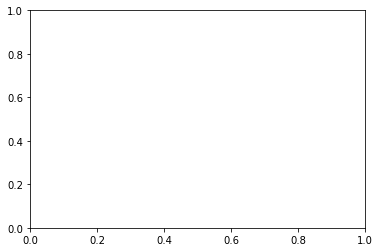

In [28]:
x_value= np.array([np.min(x[:,1]),np.max(x[:,1])])
plt.plot(x_value,y)